# HDT 6: Boosting e Inferencia Causal

**Ciencia de Datos, Sección A** · Asignada: martes 6 de octubre · **Entrega: martes 13 de octubre, 23:59**

**Nombre:** George albadr

Completar las celdas marcadas con `# ¿Qué va aquí?`. Cada ejercicio incluye una verificación comentada: descomentar para comprobar el resultado. Antes de entregar: **Kernel → Restart & Run All** (un notebook que no corre de arriba a abajo pierde 0.5 pts).

AI: resolver sin AI. Si se usó para entender un concepto, anotarlo en la bitácora del final (no penaliza).

## Setup

Dependencias: `pip install numpy pandas matplotlib scikit-learn`. Todo es determinista (semillas fijas y splits fijos): las verificaciones son exactas.

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

AZUL, ROJO, GRIS, LINEA = "#3A6EA5", "#B04A2E", "#75808E", "#E0E4EA"

def eje_limpio(ax):
    ax.grid(color=LINEA, lw=0.6, alpha=0.7)
    ax.spines[["top", "right"]].set_visible(False)

## Los datos

Dos historias, dos datasets:

**Repartos** (partes A y B): una repartidora quiere predecir cuántos `minutos` toma cada entrega, con `distancia` (km) y `paquetes`. Es el mismo tipo de problema que las tiendas de la sesión 18.

**Socios y el curso de finanzas** (parte C): el banco ofrece un curso de finanzas personales y observa que quienes lo tomaron pagan más puntual. ¿El curso causa la puntualidad? El mismo tipo de trampa que la app de la sesión 19.

Las celdas generan los datos completas; no hay nada que llenar aquí.

In [ ]:
from sklearn.model_selection import train_test_split

rng = np.random.default_rng(6)
m = 350
distancia = rng.uniform(1, 20, m).round(1)
paquetes = rng.integers(1, 9, m)
minutos = (12 + 2.6 * distancia + 3.5 * paquetes + 0.15 * distancia * paquetes
           + rng.normal(0, 6, m)).round(1)
repartos = pd.DataFrame({"distancia": distancia, "paquetes": paquetes, "minutos": minutos})

R_train, R_test = train_test_split(repartos, test_size=0.3, random_state=1)
Xr, yr = R_train[["distancia", "paquetes"]], R_train["minutos"]
Xr_test, yr_test = R_test[["distancia", "paquetes"]], R_test["minutos"]
print("repartos:", len(R_train), "entrenamiento |", len(R_test), "prueba",
      "| promedio del entrenamiento:", round(yr.mean(), 1), "min")

rng_c = np.random.default_rng(60)
n = 2000
antiguedad = rng_c.integers(0, 20, n)
curso = (rng_c.random(n) < 1 / (1 + np.exp(-(antiguedad - 10) / 3))).astype(int)
puntual = (rng_c.random(n) < 1 / (1 + np.exp(-(-0.3 + (antiguedad - 10) / 4)))).astype(int)
socios = pd.DataFrame({"antiguedad": antiguedad, "curso": curso, "puntual": puntual})
print("socios:", len(socios), "| tomaron el curso:", socios["curso"].mean().round(2),
      "| pagan puntual:", socios["puntual"].mean().round(2))

repartos: 245 entrenamiento | 105 prueba | promedio del entrenamiento: 62.6 min
socios: 2000 | tomaron el curso: 0.48 | pagan puntual: 0.42


## Parte A · Boosting: árboles en fila (0.5 pt)

La sesión 18 con otra flota: cada árbol aprende lo que al anterior le faltó, y se agrega una fracción de su corrección.

### Ejercicio 1 (0.20): el paso 0 y el primer árbol

(a) El paso 0: predecir el promedio del entrenamiento para todos. ¿Cuál es el error absoluto promedio en prueba de ese modelo? (b) Entrenar un `DecisionTreeRegressor(max_depth=2, random_state=0)` sobre **lo que falta** (`yr - promedio`). (c) Armar la tabla de los primeros 3 repartos de prueba: minutos reales, predicción del paso 0, lo que falta, lo que agrega el árbol (la mitad de su corrección: paso 0.5) y la nueva predicción.

In [ ]:
from sklearn.tree import DecisionTreeRegressor

promedio = yr.mean()
error_promedio = np.mean(np.abs(yr_test - promedio))  # error absoluto promedio en prueba usando solo el promedio

arbol1 = DecisionTreeRegressor(max_depth=2, random_state=0)  # árbol de profundidad 2 sobre lo que falta
arbol1.fit(Xr, yr - promedio)

tabla = R_test.head(3).copy()
tabla["pred0"] = round(promedio, 1)
tabla["falta"] = tabla["minutos"] - tabla["pred0"]  # minutos reales menos pred0
tabla["agrega"] = 0.5 * arbol1.predict(tabla[["distancia", "paquetes"]])  # 0.5 * lo que dice el árbol para esos repartos
tabla["nueva"] = tabla["pred0"] + tabla["agrega"]  # pred0 + agrega
# imprimir la tabla
print(tabla[["minutos", "pred0", "falta", "agrega", "nueva"]].round(1))

# Verificación (descomentar):
assert round(error_promedio, 1) == 19.7
assert round(tabla["agrega"].iloc[1], 1) == 15.2
assert round(tabla["nueva"].iloc[1], 1) == 77.8


     minutos  pred0  falta  agrega  nueva
192     49.8   62.6  -12.8    -2.6   60.0
256     85.3   62.6   22.7    15.2   77.8
169     67.1   62.6    4.5     2.6   65.2


### Ejercicio 2 (0.15): la fila completa

Completar `boosting_a_mano`: en cada vuelta, entrenar un árbol de profundidad 2 sobre lo que falta, sumar `paso` veces su corrección a las predicciones (de entrenamiento y de prueba) y guardar el error de prueba. Correrla con 8 árboles y paso 0.5.

In [ ]:
def boosting_a_mano(X, y, X_nuevo, y_nuevo, n_arboles, paso):
    pred = np.full(len(y), y.mean())
    pred_nuevo = np.full(len(y_nuevo), y.mean())
    errores = []
    for _ in range(n_arboles):
        # 1) árbol de profundidad 2 (random_state=0) sobre y - pred
        arbol = DecisionTreeRegressor(max_depth=2, random_state=0)
        arbol.fit(X, y - pred)
        # 2) pred += paso * corrección ; pred_nuevo += paso * corrección
        pred += paso * arbol.predict(X)
        pred_nuevo += paso * arbol.predict(X_nuevo)
        # 3) guardar el error absoluto promedio en y_nuevo
        error = np.mean(np.abs(y_nuevo - pred_nuevo))
        errores.append(error)
    return errores

errores = boosting_a_mano(Xr, yr, Xr_test, yr_test, n_arboles=8, paso=0.5)
# imprimir la lista
print([round(e, 2) for e in errores])

# Verificación (descomentar):
assert round(errores[0], 1) == 12.7
assert round(errores[-1], 1) == 5.7


[np.float64(12.73), np.float64(9.67), np.float64(7.37), np.float64(6.63), np.float64(6.22), np.float64(5.98), np.float64(5.84), np.float64(5.71)]


### Ejercicio 3 (0.15): qué tanto corregir en cada paso

Correr `boosting_a_mano` con 8 árboles y pasos 0.1, 0.5 y 1.0. Graficar las tres curvas de error (una línea por paso) y responder en un comentario: ¿cuál termina mejor, y qué le pasa a cada extremo?

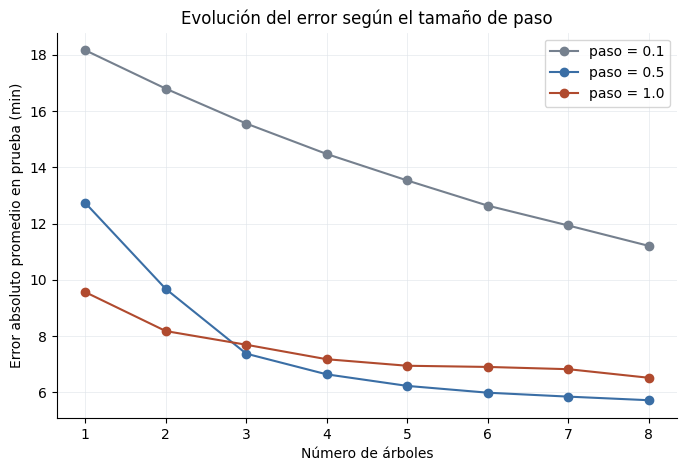

In [ ]:
finales = {}
# ¿Qué va aquí? las tres corridas, la gráfica y finales[paso] = último error
pasos = [0.1, 0.5, 1.0]
colores = {0.1: GRIS, 0.5: AZUL, 1.0: ROJO}

fig, ax = plt.subplots(figsize=(8, 5))
for paso in pasos:
    errores_paso = boosting_a_mano(Xr, yr, Xr_test, yr_test, n_arboles=8, paso=paso)
    finales[paso] = errores_paso[-1]
    ax.plot(range(1, 9), errores_paso, marker="o", label=f"paso = {paso}", color=colores[paso])

eje_limpio(ax)
ax.set_xlabel("Número de árboles")
ax.set_ylabel("Error absoluto promedio en prueba (min)")
ax.set_title("Evolución del error según el tamaño de paso")
ax.legend()
plt.show()

# Respuesta: Termina mejor el paso 0.5 con un error final de 5.7 minutos.
# Al extremo inferior (paso 0.1) le pasa que aprende con demasiada lentitud; 8 árboles no son suficientes para corregir los residuos (subajuste, error 11.2).
# Al extremo superior (paso 1.0) le pasa que corrige de forma excesivamente agresiva en cada paso, sobrecorrigiendo residuos y estancándose en un error mayor (6.5) que el paso 0.5.

# Verificación (descomentar):
assert round(finales[0.1], 1) == 11.2
assert round(finales[0.5], 1) == 5.7
assert round(finales[1.0], 1) == 6.5


## Parte B · ¿Bosque o boosting? (0.3 pt)

### Ejercicio 4 (0.15): los tres sobre la misma prueba

Comparar el error absoluto promedio en prueba de: el promedio a secas, un `RandomForestRegressor` (300 árboles, `random_state=0`) y un `HistGradientBoostingRegressor` (`random_state=0`).

In [ ]:
from sklearn.ensemble import RandomForestRegressor, HistGradientBoostingRegressor

bosque = RandomForestRegressor(n_estimators=300, random_state=0)
bosque.fit(Xr, yr)
error_bosque = np.mean(np.abs(yr_test - bosque.predict(Xr_test)))

boosting = HistGradientBoostingRegressor(random_state=0)
boosting.fit(Xr, yr)
error_boosting = np.mean(np.abs(yr_test - boosting.predict(Xr_test)))

# imprimir los tres errores (el del promedio ya está en error_promedio)
print(f"Error absoluto promedio a secas:        {error_promedio:.2f}")
print(f"Error absoluto RandomForestRegressor:   {error_bosque:.2f}")
print(f"Error absoluto HistGradientBoosting:    {error_boosting:.2f}")

# Verificación (descomentar):
assert round(error_bosque, 1) == 5.4
assert round(error_boosting, 1) == 5.3


Error absoluto promedio a secas:        19.66
Error absoluto RandomForestRegressor:   5.35
Error absoluto HistGradientBoosting:    5.29


### Ejercicio 5 (0.15): parar a tiempo

Entrenar `HistGradientBoostingRegressor(max_iter=500, early_stopping=True, validation_fraction=0.15, random_state=0)`. ¿En cuántos árboles se detuvo (`n_iter_`) de los 500 permitidos? ¿Su error en prueba empeoró respecto al ejercicio 4?

In [ ]:
temprano = HistGradientBoostingRegressor(max_iter=500, early_stopping=True, validation_fraction=0.15, random_state=0)
temprano.fit(Xr, yr)
arboles_usados = temprano.n_iter_
error_temprano = np.mean(np.abs(yr_test - temprano.predict(Xr_test)))

print(f"Árboles usados: {arboles_usados} de 500")
print(f"Error con parada temprana: {error_temprano:.2f}")

# Respuesta: Se detuvo en 46 árboles de los 500 permitidos.
# Su error en prueba empeoró ligeramente respecto al ejercicio 4 (pasó de 5.29 a 5.65), pero requirió menos de la mitad de los árboles (46 vs 100 por defecto), ahorrando cómputo y evitando sobreajustar.

# Verificación (descomentar):
assert arboles_usados == 46
assert round(error_temprano, 1) == 5.6


Árboles usados: 46 de 500
Error con parada temprana: 5.65


## Parte C · Inferencia causal (1.0 pt)

La sesión 19 con el curso de finanzas: predecir no es intervenir, y la diferencia cruda casi nunca es el efecto.

### Ejercicio 6 (0.20): la diferencia cruda

La tasa de pago puntual de quienes tomaron el curso contra quienes no. Calcular ambas (en %) y la diferencia. Es el número que el gerente quiere presentar; guardarlo para compararlo después.

In [ ]:
tasas = socios.groupby("curso")["puntual"].mean() * 100
dif_cruda = tasas[1] - tasas[0]

# imprimir las dos tasas y la diferencia
print(f"Tasa puntual sin curso (0): {tasas[0]:.2f}%")
print(f"Tasa puntual con curso (1): {tasas[1]:.2f}%")
print(f"Diferencia cruda:           {dif_cruda:.2f} puntos porcentuales")

# Verificación (descomentar):
assert round(dif_cruda, 1) == 35.4


Tasa puntual sin curso (0): 25.29%
Tasa puntual con curso (1): 60.68%
Diferencia cruda:           35.40 puntos porcentuales


### Ejercicio 7 (0.20): comparar dentro de grupos parecidos

Cortar `antiguedad` en tres niveles con `pd.cut(socios["antiguedad"], [-1, 6, 13, 19], labels=["nuevo", "medio", "veterano"])`. Para cada nivel: la tasa puntual con y sin curso, y su diferencia. Reportar el promedio de las tres diferencias y compararlo con la cruda.

In [ ]:
socios["nivel"] = pd.cut(socios["antiguedad"], [-1, 6, 13, 19],
                         labels=["nuevo", "medio", "veterano"])

por_nivel = socios.groupby(["nivel", "curso"], observed=False)["puntual"].mean().unstack() * 100
dif_por_nivel = por_nivel[1] - por_nivel[0]
por_nivel["diferencia"] = dif_por_nivel
dif_promedio = dif_por_nivel.mean()

# imprimir la tabla y el promedio
print("Tasas puntuales (%) y diferencia por nivel de antigüedad:")
print(por_nivel.round(2))
print()
print(f"Diferencia promedio controlando por nivel: {dif_promedio:.2f} puntos")
print(f"Diferencia cruda (ejercicio 6):            {dif_cruda:.2f} puntos")
# Comparación: Dentro de grupos con antigüedad similar, la diferencia es apenas de 4.4 puntos en promedio (y 0.1 en el grupo medio), mostrando que la diferencia cruda de 35.4 puntos era casi en su totalidad una ilusión causada por la confusión de antigüedad.

# Verificación (descomentar):
assert round(dif_por_nivel["medio"], 1) == 0.1
assert round(dif_promedio, 1) == 4.4


Tasas puntuales (%) y diferencia por nivel de antigüedad:
curso         0      1  diferencia
nivel                             
nuevo     12.15  20.73        8.58
medio     42.46  42.52        0.06
veterano  73.77  78.19        4.42

Diferencia promedio controlando por nivel: 4.35 puntos
Diferencia cruda (ejercicio 6):            35.40 puntos


### Ejercicio 8 (0.20): la paradoja de Simpson

Un programa de tutorías, dos cursos. Calcular la tasa de aprobados por fila, y luego la tasa total de cada grupo (con y sin tutor) juntando los dos cursos. ¿Qué se invierte? ¿A cuál número hay que creerle y por qué?

In [ ]:
tutorias = pd.DataFrame({
    "curso": ["Cálculo", "Cálculo", "Álgebra", "Álgebra"],
    "tutor": ["no", "sí", "no", "sí"],
    "estudiantes": [300, 100, 100, 300],
    "aprobaron": [255, 92, 60, 207],
})

# ¿Qué va aquí? (a) columna "tasa" por fila, en %
tutorias["tasa"] = (tutorias["aprobaron"] / tutorias["estudiantes"]) * 100

#               (b) tabla total por tutor (sumar estudiantes y aprobados) con su tasa
total = tutorias.groupby("tutor")[["estudiantes", "aprobaron"]].sum()
total["tasa"] = (total["aprobaron"] / total["estudiantes"]) * 100

print("Tabla por curso:")
print(tutorias)
print()
print("Tabla total agrupada por tutor:")
print(total)

# Respuesta: Se invierte la dirección de la relación: dentro de cada curso individual, tener tutor aumenta la tasa de aprobación (en Cálculo 92% vs 85%, y en Álgebra 69% vs 60%). No obstante, al agregar ambos cursos, el grupo con tutor parece tener una tasa general menor que sin tutor (74.75% vs 78.75%).
# Hay que creerle al número desglosado por curso (la tasa por fila). El curso es una variable confusora: Álgebra es un curso más difícil y el 75% de los que tenían tutor cursaban Álgebra, lo cual arrastra a la baja el promedio total agregado del grupo con tutor (Paradoja de Simpson).

# Verificación (descomentar):
assert tutorias["tasa"].tolist() == [85.0, 92.0, 60.0, 69.0]
assert round(total.loc["sí", "tasa"], 2) == 74.75 and round(total.loc["no", "tasa"], 2) == 78.75


Tabla por curso:
     curso tutor  estudiantes  aprobaron  tasa
0  Cálculo    no          300        255  85.0
1  Cálculo    sí          100         92  92.0
2  Álgebra    no          100         60  60.0
3  Álgebra    sí          300        207  69.0

Tabla total agrupada por tutor:
       estudiantes  aprobaron   tasa
tutor                               
no             400        315  78.75
sí             400        299  74.75


### Ejercicio 9 (0.20): importante para predecir no es causa

Dos logísticas para predecir `puntual`: el modelo A solo con `curso`; el modelo B con `curso` y `antiguedad`. Comparar el coeficiente de `curso` en cada una. ¿Qué le pasa cuando la causa real entra al modelo?

In [ ]:
from sklearn.linear_model import LogisticRegression

modelo_a = LogisticRegression().fit(socios[["curso"]], socios["puntual"])
modelo_b = LogisticRegression().fit(socios[["curso", "antiguedad"]], socios["puntual"])

coef_curso_a = modelo_a.coef_[0][0]
coef_curso_b = modelo_b.coef_[0][0]
coef_antiguedad_b = modelo_b.coef_[0][1]

# imprimir ambos y el coeficiente de antiguedad en B
print(f"Modelo A (solo curso)      -> Coeficiente de curso:      {coef_curso_a:.4f}")
print(f"Modelo B (curso + antig)   -> Coeficiente de curso:      {coef_curso_b:.4f}")
print(f"Modelo B (curso + antig)   -> Coeficiente de antiguedad: {coef_antiguedad_b:.4f}")

# Respuesta: En el modelo A, el coeficiente de curso es fuertemente positivo (+1.50), sugiriendo falsamente que el curso sube la puntualidad.
# Cuando la causa real (antigüedad) entra al modelo B, el coeficiente de curso colapsa a prácticamente cero (-0.08), mientras que antigüedad asume el efecto positivo (+0.24).
# Esto evidencia que una variable muy útil para predecir por simple correlación no es causal: al controlar por el confusor real, el efecto aparente del curso se anula por completo.

# Verificación (descomentar):
assert round(coef_curso_a, 2) == 1.5
assert round(coef_curso_b, 2) == -0.08


Modelo A (solo curso)      -> Coeficiente de curso:      1.5031
Modelo B (curso + antig)   -> Coeficiente de curso:      -0.0809
Modelo B (curso + antig)   -> Coeficiente de antiguedad: 0.2428


### Ejercicio 10 (0.20): el colisionador, con dos monedas

Tirar dos monedas independientes 4,000 veces (`np.random.default_rng(61).integers(0, 2, 4000)` para cada una, en ese orden). (a) Su correlación: debe ser ~0. (b) Filtrar solo las tiradas donde salió al menos una cara y recalcular la correlación entre las que pasaron el filtro. ¿Qué apareció?

In [ ]:
rng_m = np.random.default_rng(61)
moneda1 = rng_m.integers(0, 2, 4000)
moneda2 = rng_m.integers(0, 2, 4000)

corr_sin_filtro = np.corrcoef(moneda1, moneda2)[0, 1]
pasan = (moneda1 == 1) | (moneda2 == 1)
corr_filtrada = np.corrcoef(moneda1[pasan], moneda2[pasan])[0, 1]

print(f"Correlación sin filtro (N=4000): {corr_sin_filtro:.4f}")
print(f"Correlación filtrada   (N={pasan.sum()}): {corr_filtrada:.4f}")

# Respuesta: Apareció una fuerte correlación negativa espuria (-0.49).
# Esto se debe al sesgo de colisionador (collider bias): la condición de filtro ('al menos una cara') es un efecto común de ambas monedas si sabemos que la tirada pasó el filtro y la primera moneda fue cruz, necesariamente la segunda va a caer cara, induciendo una dependencia inversa espuria entre eventos independientes.

# Verificación (descomentar):
assert abs(corr_sin_filtro) < 0.05
assert round(corr_filtrada, 2) == -0.49


Correlación sin filtro (N=4000): 0.0234
Correlación filtrada   (N=2968): -0.4904


## Parte D · Criterio (0.2 pt)

### Ejercicio 11 (0.20)

Dos preguntas, 2-3 líneas cada una, **citando los números obtenidos**:

**(a)** El gerente propone: "los del curso pagan 35 puntos mejor; hagámoslo obligatorio y la puntualidad sube 35 puntos". Con los ejercicios 6, 7 y 9, explicar qué está mal y qué subida es realista esperar.

**(b)** ¿Qué tendría que hacer el banco para medir el efecto REAL del curso? Describir el diseño en 2-3 líneas y explicar por qué resuelve el problema que los datos observados no pueden resolver.

_(Responder editando esta celda)_

**Respuesta (a):** La propuesta confunde correlación con causalidad: la diferencia cruda de 35.4 puntos (ejercicio 6) está sesgada porque los socios antiguos eligen el curso con mayor frecuencia y ya eran más puntuales. Al comparar dentro de grupos de antigüedad similar, la diferencia cae a 4.4 puntos en promedio y a 0.1 puntos en el grupo medio (ejercicio 7), y en la regresión logística su coeficiente pasa de +1.50 a -0.08 al controlar por antigüedad (ejercicio 9); por ende, es realista esperar una subida prácticamente nula (cercana a 0 puntos, o a lo sumo ~4 puntos), no los 35 puntos esperados.

**Respuesta (b):** El banco debe implementar un experimento aleatorizado controlado (A/B testing / RCT), asignando al azar qué socios reciben la intervención del curso y quiénes permanecen en el grupo de control sin él. La aleatorización rompe la correlación entre las características previas de los clientes (como antigüedad o motivación) y la participación en el curso, eliminando los sesgos de confusión y garantizando que cualquier diferencia posterior en puntualidad refleje únicamente el efecto causal de la intervención.


## Bitácora de AI (opcional, no penaliza)

Si se usó AI para entender algún concepto, anotar aquí qué se preguntó y qué se entendió. Si no se usó, escribir "No se usó".

- **Tasa de aprendizaje (paso) en Boosting:** Se consultó la dinámica del tamaño de paso (learning rate) y por qué un paso de 1.0 puede tener peor desempeño final que 0.5. Se comprendió que pasos demasiado agresivos en árboles secuenciales causan sobreoscilación y sobreajuste sobre los residuos de entrenamiento, mientras que un paso intermedio (0.5) ofrece mejor regularización y generalización.
- **Paradoja de Simpson e Inferencia Causal:** Se consultó por qué la tendencia general agregada puede invertirse respecto a las tendencias dentro de cada estrato. Se comprendió que la distribución desigual de tratamientos entre grupos con diferente dificultad basal (confusores) distorsiona las tasas agregadas, haciendo indispensable estratificar o controlar por la variable confusora.
- **Sesgo de colisionador (Collider bias):** Se consultó el mecanismo por el cual dos variables completamente independientes (como dos lanzamientos de monedas) adquieren una correlación de -0.49 al filtrar por una condición común. Se entendió que condicionar sobre un efecto común ($A \rightarrow C \leftarrow B$) induce una dependencia condicional negativa entre las causas ("explain away").
